# U-Net++
## Full pipeline for training:
```text
Batch of 2.5D samples
    ↓
U-Net++ 
Input:  [B, 3, H, W]
Output: [B, 1, H, W] (logits)
    ↓
Loss function
0.45 * Dice + 0.45 * BCE + 0.1 * Tversky loss
    ↓
Backpropagation (update model weights) + AdamW optimizer
    ↓
Validation metrics + best checkpoint saved
```
## Inference
```text
CT sample [3, H, W]
    ↓
U-Net++
    ↓
logits [1, H, W]
    ↓ sigmoid
probability map [1, H, W]
    ↓ threshold
binary CAC mask [1, H, W] for center slice k
```

The model outputs raw logits, not probabilities. Sigmoid and thresholding are applied during validaiton, testing, qualitative visualization, and inference.

In [1]:
import os

os.listdir("/kaggle/input/datasets/kaleykim297")

['case-splits-context', 'segmentation-cac']

In [2]:
os.chdir("/kaggle/input/datasets/kaleykim297/segmentation-cac")

In [4]:
from pathlib import Path

for p in Path("/kaggle/input").rglob("*"):
    if p.suffix in [".pt", ".pth", ".zip", ".csv"]:
        print(p)

/kaggle/input/datasets/kaleykim297/case-splits-context/case_splits_context.csv
/kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/case_splits.csv
/kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/processing_manifest.csv
/kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/xml_roi_audit.csv
/kaggle/input/notebooks/kaleykim297/unetmodel/checkpoints++_backup.zip
/kaggle/input/notebooks/kaleykim297/unetmodel/checkpoints++/latest_checkpoint.pt
/kaggle/input/notebooks/kaleykim297/unetmodel/checkpoints++/best_weights.pt
/kaggle/input/notebooks/kaleykim297/unetmodel/checkpoints++/best_checkpoint.pt


In [8]:
from pathlib import Path
import shutil

src_dir = Path("/kaggle/input/notebooks/kaleykim297/unetmodel/checkpoints++")  # change this
dst_dir = Path("/kaggle/working/checkpoints++")

dst_dir.mkdir(parents=True, exist_ok=True)

for f in src_dir.glob("*"):
    shutil.copy2(f, dst_dir / f.name)

print("Copied files:")
for p in dst_dir.iterdir():
    print(p)

Copied files:
/kaggle/working/checkpoints++/best_weights.pt
/kaggle/working/checkpoints++/latest_checkpoint.pt
/kaggle/working/checkpoints++/best_checkpoint.pt


## Use GPU for image processing (cuda)

In [10]:
from pathlib import Path
import random, time
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tqdm.auto import tqdm
from scipy.ndimage import label, binary_erosion, distance_transform_edt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## Inspect 1 .npy case
Create checkpoint paths

In [11]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the project folder that contains processed_data/images."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "processed_data" / "images").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find processed_data/images from {start}. "
        "Run this notebook from inside the project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "processed_data"
IMAGE_DIR = DATA_ROOT / "images"
MASK_DIR = DATA_ROOT / "masks"

# CHECKPOINT paths
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints++")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(CHECKPOINT_DIR.exists())

LATEST_CKPT_PATH = CHECKPOINT_DIR / "latest_checkpoint.pt"
BEST_CKPT_PATH = CHECKPOINT_DIR / "best_checkpoint.pt"
BEST_WEIGHTS_PATH = CHECKPOINT_DIR / "best_weights.pt"

case_id = "001"
image_path = IMAGE_DIR / f"{case_id}.npy"
mask_path = MASK_DIR / f"{case_id}.npy"

print("Project root:", PROJECT_ROOT)
print("Image path:", image_path)
print("Mask path:", mask_path)

images = np.load(image_path, mmap_mode="r")
masks = np.load(mask_path, mmap_mode="r")

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)

print("Image min:", images.min())
print("Image max:", images.max())

print("Mask unique values:", np.unique(masks))
print("Total positive mask pixels:", masks.sum())

True
Project root: /kaggle/input/datasets/kaleykim297/segmentation-cac
Image path: /kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/images/001.npy
Mask path: /kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/masks/001.npy
Images shape: (57, 3, 512, 512)
Masks shape: (57, 1, 512, 512)
Images dtype: float32
Masks dtype: uint8
Image min: 0.0
Image max: 1.0
Mask unique values: [0 1]
Total positive mask pixels: 1115


In [12]:
col_counts = np.count_nonzero(masks > 0)
col_counts

1115

## Config & Helpers
Storing paths, specifications about data.

This model is different from the other two because its reproducibility is assured.
`deterministic` = True
`benchmark` = False

In [15]:
@dataclass
class CFG:
    DATA_ROOT: Path = DATA_ROOT
    INPUT_DIRNAME: Path = IMAGE_DIR
    MASK_DIRNAME: Path = MASK_DIR
    SPLIT_CSV: str = "case_splits_context.csv"

    BATCH_SIZE: int = 8
    NUM_WORKERS: int = 0
    PIN_MEMORY: bool = torch.cuda.is_available()

    SEED: int = 42
    EPOCHS: int = 15
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-5
    MASK_THRESHOLD: float = 0.7

cfg = CFG()

INPUT_DIR = cfg.INPUT_DIRNAME
MASK_DIR = cfg.MASK_DIRNAME
SPLIT_PATH = Path("/kaggle/input/datasets/kaleykim297/case-splits-context") / cfg.SPLIT_CSV

print("Input dir:", INPUT_DIR)
print("Mask dir:", MASK_DIR)
print("Split CSV:", SPLIT_PATH)

Input dir: /kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/images
Mask dir: /kaggle/input/datasets/kaleykim297/segmentation-cac/processed_data/masks
Split CSV: /kaggle/input/datasets/kaleykim297/case-splits-context/case_splits_context.csv


In [16]:
# Prioritize speed, not perfect reproducibility
# deterministic = False: allows faster CUDA algorithms, but results may vary slightly between runs
# benchmark = True: lets cuDNN test different conv algorithms and choose the fastest one.
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)
USE_AMP = DEVICE.type == "cuda"
# Speed up U-Net training
USE_CHANNELS_LAST = DEVICE.type == "cuda"

In [17]:
def fmt(v):
    return "None" if v is None else f"{v:.4f}"

## Load split table and verify case files

Example structure
| case_id | split | % |
|---|---|---|
| case_001 | train | 70 |
| case_002 | val | 15 |
| case_003 | test | 15 |

convert `case_id` to string form, convert column to lowercase, remove spaces at start/end.

In [19]:
assert SPLIT_PATH.exists(), f"Missing split CSV: {SPLIT_PATH}"

splits_df = pd.read_csv(SPLIT_PATH)
required_cols = {"case_id", "split"}
assert required_cols.issubset(splits_df.columns), f"Missing columns: {required_cols - set(splits_df.columns)}"

splits_df["case_id"] = splits_df["case_id"].astype(str)
splits_df["split"] = splits_df["split"].str.lower().str.strip()

print(splits_df["split"].value_counts())
splits_df.head()

split
train    314
test      68
val       67
Name: count, dtype: int64


,case_id,split
0,229,train
1,421,train
2,119,train
3,115,train
4,169,train


In [20]:
def input_path_for(case_id: str) -> Path:
    return INPUT_DIR / f"{case_id}.npy"

def mask_path_for(case_id: str) -> Path:
    return MASK_DIR / f"{case_id}.npy"

manifest = []
for _, row in splits_df.iterrows():
    case_id = f"{int(row['case_id']):03d}"
    input_path = input_path_for(case_id)
    mask_path = mask_path_for(case_id)

    manifest.append({
        "case_id": case_id,
        "split": row["split"],
        "input_path": str(input_path),
        "mask_path": str(mask_path),
        "input_exists": input_path.exists(),
        "mask_exists": mask_path.exists(),
    })

manifest_df = pd.DataFrame(manifest)

print("Missing input files:", (~manifest_df["input_exists"]).sum())
print("Missing mask files:", (~manifest_df["mask_exists"]).sum())

assert manifest_df["input_exists"].all(), "Some input files are missing."
assert manifest_df["mask_exists"].all(), "Some mask files are missing."

manifest_df.head()

Missing input files: 0
Missing mask files: 0


,case_id,split,input_path,mask_path,input_exists,mask_exists
0,229,train,/kaggle/input/datasets/kaleykim297/segmentatio...,/kaggle/input/datasets/kaleykim297/segmentatio...,True,True
1,421,train,/kaggle/input/datasets/kaleykim297/segmentatio...,/kaggle/input/datasets/kaleykim297/segmentatio...,True,True
2,119,train,/kaggle/input/datasets/kaleykim297/segmentatio...,/kaggle/input/datasets/kaleykim297/segmentatio...,True,True
3,115,train,/kaggle/input/datasets/kaleykim297/segmentatio...,/kaggle/input/datasets/kaleykim297/segmentatio...,True,True
4,169,train,/kaggle/input/datasets/kaleykim297/segmentatio...,/kaggle/input/datasets/kaleykim297/segmentatio...,True,True


## Strict array validation
Load image tensor and mask tensor, count for each sample, how many positive mask pixels exist.
Expected:
- input: `(K, 3, H, W)`
- mask: `(K, 1, H, W)`

Where:
* `K` = number of 2.5D samples in the case
* `3` = three adjacent CT slices
* `1` center-slice binary CAC mask

The code also counts positive mask pixels to verify whether CAC-positive samples exist.

In [21]:
case_stats = []

for _, row in manifest_df.iterrows():
    x = np.load(row["input_path"], mmap_mode="r")
    y = np.load(row["mask_path"], mmap_mode="r")
    
    assert x.ndim == 4, f"{row['case_id']}: input shape must be (N, 3, H, W), got {x.shape}"
    assert y.ndim == 4, f"{row['case_id']}: mask shape must be (N,1,H,W), got {y.shape}"
    assert x.shape[0] == y.shape[0], f"{row['case_id']}: number of samples mismatch."
    assert x.shape[1] == 3, f"{row['case_id']}: expected 3 input channels, got {x.shape[1]}"
    assert y.shape[1] == 1, f"{row['case_id']}: expected 1 mask channel, got {y.shape[1]}"
    assert x.shape[-2:] == y.shape[-2:], f"{row['case_id']}: spatial mismatch."

    positive_per_sample = np.sum(y > 0, axis=(1, 2, 3)) > 0

    case_stats.append({
        "case_id": row["case_id"],
        "split": row["split"],
        "num_samples": int(x.shape[0]),
        "height": int(x.shape[2]),
        "width": int(x.shape[3]),
        "positive_samples": int(positive_per_sample.sum()),
        "positive_pixels": int(np.sum(y > 0)),
        "x_min": float(np.min(x)),
        "x_max": float(np.max(x)),
    })

case_stats_df = pd.DataFrame(case_stats)
print("All cases passed validation.")
case_stats_df.head()

All cases passed validation.


,case_id,split,num_samples,height,width,positive_samples,positive_pixels,x_min,x_max
0,229,train,48,512,512,6,289,0.0,1.0
1,421,train,51,512,512,2,72,0.0,1.0
2,119,train,45,512,512,20,3435,0.0,1.0
3,115,train,41,512,512,6,621,0.0,1.0
4,169,train,51,512,512,1,31,0.0,1.0


In [24]:
summary_df = (
    case_stats_df
    .groupby("split")
    .agg(
        cases=("case_id", "nunique"),
        total_samples=("num_samples", "sum"),
        positive_samples=("positive_samples", "sum"),
        positive_pixels=("positive_pixels", "sum"),
    )
    .reset_index()
)

summary_df["positive_sample_ratio"] = summary_df["positive_samples"] / summary_df["total_samples"]
summary_df

,split,cases,total_samples,positive_samples,positive_pixels,positive_sample_ratio
0,test,68,3478,540,66660,0.155262
1,train,314,16098,2568,387014,0.159523
2,val,67,3416,550,79457,0.161007


## Visual sanity check

Must inspect at least several positive samples before training. If mask alignment is wrong, stop.
* the center CT slice aligns with the mask
* the mask is not shifted, flipped, or empty by mistake
* positive samples are actually present
* the 2.5D input order is reasonable: `k-1`, `k`, `k+1`

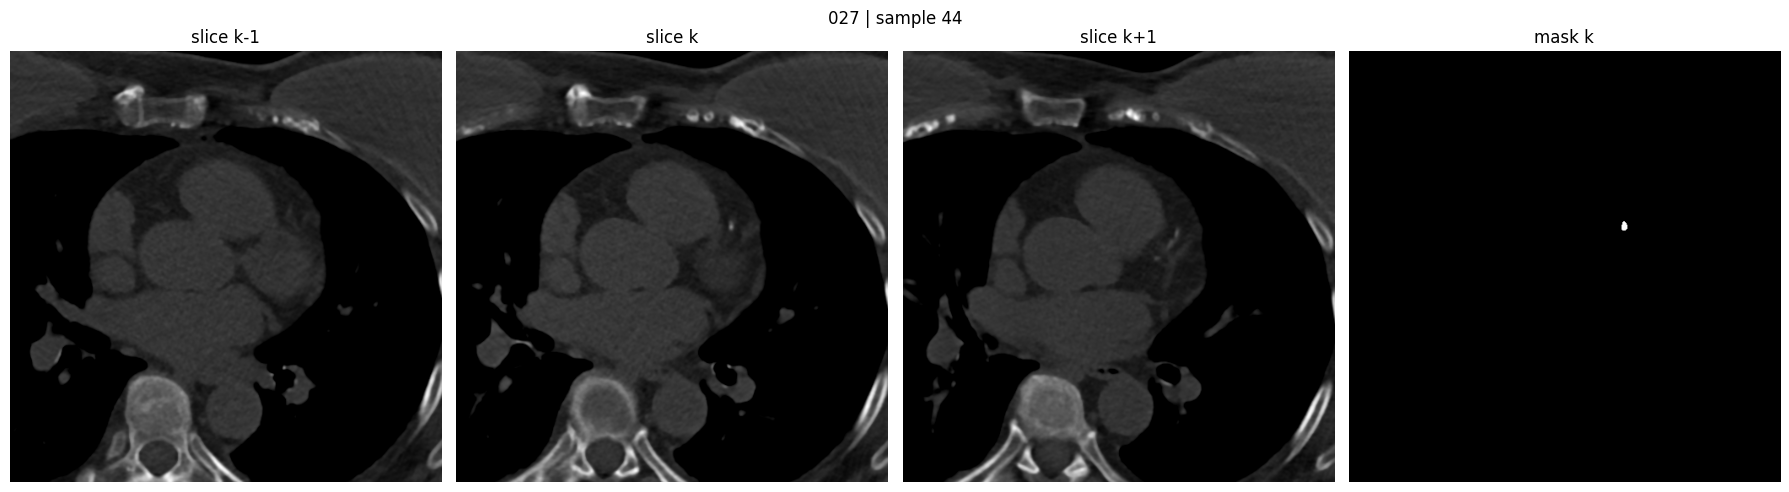

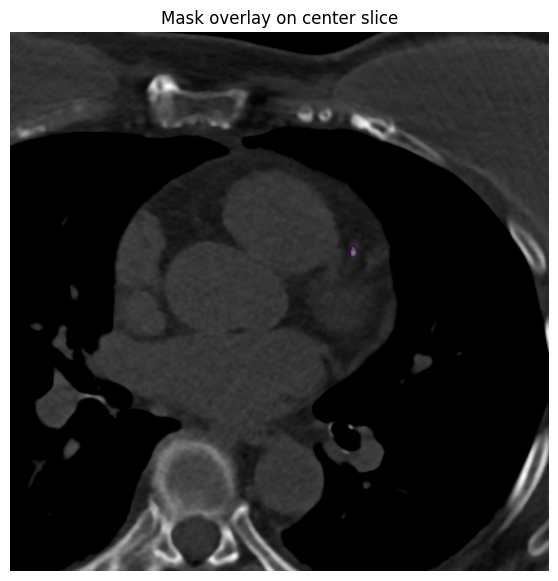

In [25]:
def load_positive_sample(case_id: str):
    row = manifest_df[manifest_df["case_id"] == case_id].iloc[0]
    x = np.load(row["input_path"], mmap_mode="r")
    y = np.load(row["mask_path"], mmap_mode="r")

    positive_idx = np.where(np.sum(y > 0, axis=(1, 2, 3)) > 0)[0]
    # Safe stoppage
    if len(positive_idx) == 0:
        return None
    
    idx = int(positive_idx[0])
    return np.array(x[idx]), np.array(y[idx]), idx

positive_cases = case_stats_df[case_stats_df["positive_samples"] > 0]["case_id"].tolist()
assert positive_cases, "No positive_masks found."

# Loads random case that has positive slices
case_id = random.choice(positive_cases)
x_sample, y_sample, sample_idx = load_positive_sample(case_id)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, title in enumerate(["slice k-1", "slice k", "slice k+1"]):
    axes[i].imshow(x_sample[i], cmap="gray")
    axes[i].set_title(title)
    axes[i].axis("off")

axes[3].imshow(y_sample[0], cmap="gray")
axes[3].set_title("mask k")
axes[3].axis("off")
plt.suptitle(f"{case_id} | sample {sample_idx}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(x_sample[1], cmap="gray")
if y_sample[0].max() > 0:
    plt.contour(y_sample[0], levels=[0.5], linewidths=1)
plt.title("Mask overlay on center slice")
plt.axis("off")
plt.show()

## Flatten case-level `.npy` arrays into sample-level index
converts from a case-level into a sample-level table (3 slices). Identifying positive slices help for later `oversampling`, computing `pos/neg sample counts`, monitoring `class imbalance`.

The sample-level index stores:
* case ID
* split
* image path
* mask path
* sample index inside the case
* whether the center mask contains CAC

This index is used by the PyTorch Dataset and by the sampler.

In [26]:
def build_sample_index(manifest_subset: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in manifest_subset.iterrows():
        x = np.load(row["input_path"], mmap_mode="r")
        y = np.load(row["mask_path"], mmap_mode="r")
        # Determine which samples contain CAC
        positive = np.sum(y > 0, axis=(1,2,3)) > 0

        # Storing metadata
        for sample_idx in range(x.shape[0]):
            rows.append({
                "case_id": row["case_id"],
                "split": row["split"],
                "input_path": row["input_path"],
                "mask_path": row["mask_path"],
                "sample_idx": sample_idx,
                "has_cac": int(positive[sample_idx]),
            })

    return pd.DataFrame(rows)

train_index_df = build_sample_index(manifest_df[manifest_df["split"] == "train"])
val_index_df = build_sample_index(manifest_df[manifest_df["split"] == "val"])
test_index_df = build_sample_index(manifest_df[manifest_df["split"] == "test"])

print("Train:", len(train_index_df))
print("Val:", len(val_index_df))
print("Test:", len(test_index_df))
print("\nTrain label ratio:")
print(train_index_df["has_cac"].value_counts(normalize=True))

Train: 16098
Val: 3416
Test: 3478

Train label ratio:
has_cac
0    0.840477
1    0.159523
Name: proportion, dtype: float64


## PyTorch Dataset
The Dataset loads 2.5D image samples and their corresponding center-slice masks.

For each sample:
```text
image:      [3, H, W]
mask:       [1, H, W]
case_id:    source case identifier
sample_idx: sample position inside the case
has_cac:    whether the center mask contains any CAC pixels
```

The Dataset uses memory-mapped `.npy` loading to avoid loading all cases fully into RAM at once.

In [28]:
class SegmentationDataset(Dataset):
    def __init__(self, index_df: pd.DataFrame):
        self.index_df = index_df.reset_index(drop=True)
        self._input_cache = {}
        self._mask_cache = {}

    def __len__(self):
        return len(self.index_df)

    def _load_case(self, input_path: str, mask_path: str):
        if input_path not in self._input_cache:
            self._input_cache[input_path] = np.load(input_path, mmap_mode="r")
        if mask_path not in self._mask_cache:
            self._mask_cache[mask_path] = np.load(mask_path, mmap_mode="r")
        return self._input_cache[input_path], self._mask_cache[mask_path]

    def __getitem__(self, idx):
        row = self.index_df.iloc[idx]
        x_case, y_case = self._load_case(row["input_path"], row["mask_path"])

        x = np.array(x_case[int(row["sample_idx"])], dtype=np.float32)
        y = np.array(y_case[int(row["sample_idx"])], dtype=np.float32)
        y = (y > 0).astype(np.float32)

        return {
            "image": torch.from_numpy(x),
            "mask": torch.from_numpy(y),
            "case_id": row["case_id"],
            "sample_idx": int(row["sample_idx"]),
            "has_cac": int(row["has_cac"]),
        }

train_ds = SegmentationDataset(train_index_df)
val_ds = SegmentationDataset(val_index_df)
test_ds = SegmentationDataset(test_index_df)

print(len(train_ds), len(val_ds), len(test_ds))

16098 3416 3478


## Weighted sampler for lack of positive masks

Use this for **training only**. Validation/test remain naturally distributed.
Weights mean they will be drawn/called more times than those who are notv weighted.


In [29]:
def make_weighted_sampler(index_df: pd.DataFrame, positive_weight: float = 5.0):
    weights = np.where(index_df["has_cac"].values == 1, positive_weight, 1.0).astype(np.float64)
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights),
        num_samples=len(weights),
        replacement=True,
    )

train_sampler = make_weighted_sampler(train_index_df, positive_weight=5.0)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

batch = next(iter(train_loader))
print("Images:", batch["image"].shape)
print("Masks:", batch["mask"].shape)
print("Positive masks in sampled batch:", batch["has_cac"].sum().item())


Images: torch.Size([8, 3, 512, 512])
Masks: torch.Size([8, 1, 512, 512])
Positive masks in sampled batch: 1


## Model section

Model contract:

```text
        Input : [B, 3, H, W] (B = Batch Size)
                            ↓
Encoder: extract richer features while shrinking resolution
                            ↓
    Bottleneck: deepest, most abstract representation
                            ↓
Decoder: restore resolution while combining encoder details
                            ↓
                        1×1 Conv
                            ↓
        Output logits mask : [B, 1, H, W] logits
```

Do **not** apply sigmoid inside the model. Use logits for `BCEWithLogitsLoss`.


### Encoder

The encoder progressively reduces spatial resolution while increasing channel depth

```text
x0_0: DoubleConv                     3 → 32 channels
x1_0: DownBlock                     32 → 64 channels
x2_0: DownBlock                    64 → 128 channels
x3_0: DownBlock                   128 → 256 channels
x4_0: DownBlock                   256 → 512 channels
```

`DownBlock`: MaxPool2D -> DoubleConv

### Decoder
Unlike baseline, U-Net++ does not use a simple sequential decoder with one skip connection per level. Instead, it uses **nested dense skip pathways**

The decoder nodes are:

```text
x0_1, x0_2, x0_3, x0_4
x1_1, x1_2, x1_3
x2_1, x2_2
x3_1
```


In [30]:
# Two layers learn richer local patterns: edges, bright dense structures, shape boundaries, lesion-like textures.
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.block(x)
    
def upsample_to(x, target):
    return nn.functional.interpolate(
        x,
        size=target.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )

# Downsampling block : shrinks spatial size, increase semantic richness
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)
    
# 2.5D U-Net
class UplusModel(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        base_channels=32
    ):
        super().__init__()

        # Encoder
        self.conv0_0 = DoubleConv(in_channels, base_channels)                # 32
        self.enc1 = DownBlock(base_channels, base_channels * 2)              # 64
        self.enc2 = DownBlock(base_channels * 2, base_channels * 4)          # 128
        self.enc3 = DownBlock(base_channels * 4, base_channels * 8)          # 256
        self.enc4 = DownBlock(base_channels * 8, base_channels * 16)         # 512
        
        # Nested decoder nodes
        self.conv0_1 = DoubleConv(base_channels * 3, base_channels)
        self.conv1_1 = DoubleConv(base_channels * 6, base_channels * 2)
        self.conv2_1 = DoubleConv(base_channels * 12, base_channels * 4)
        self.conv3_1 = DoubleConv(base_channels * 24, base_channels * 8)

        self.conv0_2 = DoubleConv(base_channels * 4, base_channels)
        self.conv1_2 = DoubleConv(base_channels * 8, base_channels * 2)
        self.conv2_2 = DoubleConv(base_channels * 16, base_channels * 4)

        self.conv0_3 = DoubleConv(base_channels * 5, base_channels)
        self.conv1_3 = DoubleConv(base_channels * 10, base_channels * 2)

        self.conv0_4 = DoubleConv(base_channels * 6, base_channels)

        # Final segmentation head
        self.final = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder column
        x0_0 = self.conv0_0(x)       # [B, 32, H, W]
        x1_0 = self.enc1(x0_0)       # [B, 64, H/2, W/2]
        x2_0 = self.enc2(x1_0)       # [B, 128, H/4, W/4]
        x3_0 = self.enc3(x2_0)       # [B, 256, H/8, W/8]
        x4_0 = self.enc4(x3_0)       # [B, 512, H/16, W/16]

        # First nested level
        x0_1 = self.conv0_1(
            torch.cat(
                [x0_0, upsample_to(x1_0, x0_0)],
                dim=1,
            )
        )

        x1_1 = self.conv1_1(
            torch.cat(
                [x1_0, upsample_to(x2_0, x1_0)],
                dim=1,
            )
        )

        x2_1 = self.conv2_1(
            torch.cat(
                [x2_0, upsample_to(x3_0, x2_0)],
                dim=1
            )
        )
        
        x3_1 = self.conv3_1(
            torch.cat(
                [x3_0, upsample_to(x4_0, x3_0)],
                dim=1
            )
        )

        # Second nested level
        x0_2 = self.conv0_2(
            torch.cat(
                [x0_0, x0_1, upsample_to(x1_1, x0_0)],
                dim=1,
            )
        )

        x1_2 = self.conv1_2(
            torch.cat(
                [x1_0, x1_1, upsample_to(x2_1, x1_0)],
                dim=1,
            )
        )

        x2_2 = self.conv2_2(
            torch.cat(
                [x2_0, x2_1, upsample_to(x3_1, x2_0)],
                dim=1,
            )
        )

        # Third nested level
        x0_3 = self.conv0_3(
            torch.cat(
                [x0_0, x0_1, x0_2, upsample_to(x1_2, x0_0)],
                dim=1,
            )
        )

        x1_3 = self.conv1_3(
            torch.cat(
                [x1_0, x1_1, x1_2, upsample_to(x2_2, x1_0)],
                dim=1,
            )
        )

        # Fourth nested high-resolution node
        x0_4 = self.conv0_4(
            torch.cat(
                [x0_0, x0_1, x0_2, x0_3, upsample_to(x1_3, x0_0)],
                dim=1,
            )
        )

        logits = self.final(x0_4)
        return logits
    
model = UplusModel(
    in_channels=3,
    out_channels=1,
    base_channels=32
).to(DEVICE)

if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

batch = next(iter(train_loader))
x = batch["image"].to(DEVICE)

model.eval()
with torch.no_grad():
    logits = model(x) # raw unbounded scores, passed to sigmoid for probabilities

print("Input shape:", x.shape)
print("Output shape:", logits.shape)

Input shape: torch.Size([8, 3, 512, 512])
Output shape: torch.Size([8, 1, 512, 512])


## Loss functions

* Baseline: **Dice + BCEWithLogitsLoss**.
* Optimizeer: AdamW. Handling weight decay more cleanly.
* LR Scheduler: ReduceLROnPlateau.
* AMP uses `autocast` for the forward/loss computation and `GradScaler` to keep FP16 gradients numerically stable.

The segmentation head outputs logits. Sigmoid is applied during loss commputation and threshold-based inference, consistent with BCEWithLogitsLoss

$$Dice = \frac{2 \times |Prediction \cap Target|}{|Prediction| + |Target|}$$

`BCEWithLogitsLoss`: for each pixel, should this be background `0` or CAC `1`.
Internally, it becomes $$sigmoid(logits) + \text{binary cross entropy}$$

| Dice loss helps with: | BCE helps with: |
|---|---|
| overlap quality | stable px-level optimization |
| small lesion segmentation | suppressing fp |
| class imbalance | more informative gradients early in training |

In [57]:
# Overlap with true CAC mask
# Dice = 
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # Convert logits to probabilities
        probs = torch.sigmoid(logits)
        targets = targets.float()
        dims = (1, 2, 3)

        intersection = torch.sum(probs * targets, dims)
        denominator = torch.sum(probs, dims) + torch.sum(targets, dims)
        dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
        # DiceLoss = 1 - Dice
        return 1 - dice.mean()

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        dims = (1, 2, 3)

        tp = torch.sum(probs * targets, dims)
        fp = torch.sum(probs * (1 - targets), dims)
        fn = torch.sum((1 - probs) * targets, dims)

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        return 1.0 - tversky.mean()

# Combine overlap learning + pixel classification
# Actual training loss
class DiceBCETverskyLoss(nn.Module):
    def __init__(
        self,
        dice_weight=0.45, bce_weight=0.45, tversky_weight=0.1,
        alpha=0.7, beta=0.3,
    ):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.tversky = TverskyLoss(alpha=alpha, beta=beta)

        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.tversky_weight = tversky_weight

    def forward(self, logits, targets):
        return (
            self.dice_weight * self.dice(logits, targets)
            + self.bce_weight * self.bce(logits, targets)
            + self.tversky_weight * self.tversky(logits, targets)
        )

criterion = DiceBCETverskyLoss(
    dice_weight=0.45, bce_weight=0.45, tversky_weight=0.1,
    alpha=0.7, beta=0.3,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)

# Monitor the appropriacy of Learning Rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, threshold=1e-4, min_lr=1e-6,
)
# Using AMP
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

## Resume checkpoint
Continue on what the model has been trained on

In [32]:
def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device="cuda"):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint.get("history", [])
    best_score = checkpoint.get("best_score", -1.0)

    print(f"Resumed from epoch {checkpoint['epoch']}")
    print(f"Next epoch: {start_epoch}")
    print(f"Best composite score: {best_score:.4f}")

    return start_epoch, history, best_score

In [33]:
if LATEST_CKPT_PATH.exists():
    start_epoch, history, best_score = load_checkpoint(
        LATEST_CKPT_PATH, model, optimizer, scheduler, scaler, device=DEVICE,
    )
else:
    start_epoch = 1
    history = []
    best_score = -1.0

Resumed from epoch 10
Next epoch: 11
Best composite score: 0.8738


## Segmentation metrics

Implemented:
- Dice
- IoU
- Precision
- Recall
- lesion-level sensitivity

Add later:
- HD95
- Focal Tversky Loss

In [34]:
def compute_metrics(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = targets.float()

    dims = (1, 2, 3)
    tp = torch.sum(preds * targets, dims)
    fp = torch.sum(preds * (1 - targets), dims)
    fn = torch.sum((1 - preds) * targets, dims)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = torch.where(
        (tp + fp) > 0,
        tp / (tp + fp + eps),
        torch.zeros_like(tp)
    )
    
    recall = torch.where(
        (tp + fn) > 0,
        tp / (tp + fn + eps),
        torch.zeros_like(tp)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item(),
    }

### Lesion sensitivity metrics
Compute how many ROIs are actually detected.

In [37]:
def compute_lesion_metrics_for_slice(pred_mask, gt_mask):
    """
    pred_mask, gt_mask: 2D numpy arrays with values 0/1
    Returns lesion-level counts for one slice.
    """
    pred_mask = pred_mask.astype(np.uint8)
    gt_mask = gt_mask.astype(np.uint8)

    # 8-connected neighborhoods
    structure = np.ones((3, 3), dtype=np.uint8)

    gt_labeled, n_gt = label(gt_mask, structure=structure)
    pred_labeled, n_pred = label(pred_mask, structure=structure)

    detected_gt_lesions = 0
    fp_pred_lesions = 0

    # GT lesion detection
    for gt_id in range(1, n_gt + 1):
        gt_component = gt_labeled == gt_id
        if np.any(pred_mask[gt_component] > 0):
            detected_gt_lesions += 1

    # Predicted lesion fp
    for pred_id in range(1, n_pred + 1):
        pred_component = pred_labeled == pred_id
        if not np.any(gt_mask[pred_component] > 0):
            fp_pred_lesions += 1
    
    return {
        "gt_lesions": n_gt,
        "pred_lesions": n_pred,
        "detected_gt_lesions": detected_gt_lesions,
        "fp_pred_lesions": fp_pred_lesions,
    }

## HD95
$$HD_{95} = \max(P_{95}(A \to B), P_{95}(B \to A))$$

In [38]:
def extract_binary_surface(mask: np.ndarray) -> np.ndarray:
    """
    Return the boundary pixels of a binary mask.
    """
    mask = mask.astype(bool)
    if not mask.any():
        return mask
    
    structure = np.ones((3, 3), dtype=bool)
    eroded = binary_erosion(mask, structure=structure, border_value=0)
    surface = mask ^ eroded
    
    return surface

def compute_hd95_2d(pred_mask: np.ndarray, gt_mask: np.ndarray, spacing=None):
    """
    Symmetric HD95 between two 2D binary masks.

    Returns:
        finite float if both masks are non-empty
        np.nan if either mask is empty
    """
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)

    if not pred_mask.any() or not gt_mask.any():
        return np.nan
    
    pred_surface = extract_binary_surface(pred_mask)
    gt_surface = extract_binary_surface(gt_mask)

    # Distance to nearest GT surface
    dist_to_gt = distance_transform_edt(
        ~gt_surface, sampling=spacing,
    )

    # Distance to nearest predicted surface
    dist_to_pred = distance_transform_edt(
        ~pred_surface, sampling=spacing
    )

    pred_to_gt = dist_to_gt[pred_surface]
    gt_to_pred = dist_to_pred[gt_surface]

    hd95_pred_to_gt = np.percentile(pred_to_gt, 95)
    hd95_gt_to_pred = np.percentile(gt_to_pred, 95)

    # Symmetric HD95
    return float(max(hd95_pred_to_gt, hd95_gt_to_pred))

## Checkpoint saving function

In [39]:
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler, history, best_score):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "history": history,
            "best_score": best_score,
        },
        path
    )

## Train/validation loop skeleton

### Lesion metrics
This is a 2D slice-level lesion analysis.

In [41]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    running_loss = 0.0
    metrics_store = {"dice": [], "iou": [], "precision": [], "recall": []}

    pbar = tqdm(loader, desc="Training", leave=False)

    for batch in pbar:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)
        
        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        
        total_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * x.size(0)

        metrics = compute_metrics(logits.detach(), y, threshold=cfg.MASK_THRESHOLD)

        for k, v in metrics.items():
            metrics_store[k].append(v)

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = {k: float(np.mean(v)) for k, v in metrics_store.items()}
    return epoch_loss, epoch_metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold=cfg.MASK_THRESHOLD, eps=1e-6):
    model.eval()
    running_loss = 0.0
    
    # Storing the metrics of full epoch, both neg and pos slices.
    full_metrics = {"dice": [], "iou": [], "precision": [], "recall": []}

    # Storing the metrics of positive slices only
    pos_metrics = {"pos_dice": [], "pos_precision": [], "pos_recall": []}

    # Negative slice false positives
    neg_false_metrics = {"neg_fp_pixels": [], "neg_pred_positive_samples": 0, "neg_total_samples": 0}

    # Global metrics
    global_px_counts = {
        "tp": 0.0,
        "fp": 0.0,
        "fn": 0.0,
    }

    hd95_metrics = {
        "values": [],
        "gt_no_pred_count": 0,
    }

    # Lesions debugging
    lesion_counts = {
        "gt_lesions": 0,
        "pred_lesions": 0,
        "detected_gt_lesions": 0,
        "fp_pred_lesions": 0,
    }

    pbar = tqdm(loader, desc="Validation", leave=False)

    for batch in pbar:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)
        
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = model(x)
            loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(y.size(0)):
            gt = y[i]
            pred = preds[i]

            tp = (pred * gt).sum()
            fp = (pred * (1 - gt)).sum()
            fn = ((1 - pred) * gt).sum()

            # ------------------
            # Global metrics
            # ------------------
            global_px_counts["tp"] += tp.item()
            global_px_counts["fp"] += fp.item()
            global_px_counts["fn"] += fn.item()

            # ------------------
            # All-slice metrics
            # ------------------
            dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
            iou = (tp + eps) / (tp + fp + fn + eps)

            if (tp + fp) > 0:
                precision = tp / (tp + fp + eps)
            else:
                precision = torch.tensor(0.0, device=device)
            
            if (tp + fn) > 0:
                recall = tp / (tp + fn + eps)
            else:
                recall = torch.tensor(0.0, device=device)
            
            full_metrics["dice"].append(dice.item())
            full_metrics["iou"].append(iou.item())
            full_metrics["precision"].append(precision.item())
            full_metrics["recall"].append(recall.item())

            # ------------------
            # Pos / Neg split
            # ------------------
            gt_has_cac = gt.sum() > 0

            if gt_has_cac:
                pos_metrics["pos_dice"].append(dice.item())
                pos_metrics["pos_precision"].append(precision.item())
                pos_metrics["pos_recall"].append(recall.item())
            else:
                neg_false_metrics["neg_total_samples"] += 1
                neg_false_metrics["neg_fp_pixels"].append(fp.item())
                if pred.sum() > 0:
                    neg_false_metrics["neg_pred_positive_samples"] += 1

            # ------------------
            # Lesion evaluation
            # ------------------
            pred_np = pred.squeeze().detach().cpu().numpy().astype(np.uint8)
            gt_np = gt.squeeze().detach().cpu().numpy().astype(np.uint8)
            lesion_res = compute_lesion_metrics_for_slice(
                pred_np, gt_np,
            )

            for k in lesion_counts:
                lesion_counts[k] += lesion_res[k]

            # ------------------
            # HD95 evaluation
            # Positive GT slices only
            # ------------------
            if gt_np.any():
                if pred_np.any():
                    hd95_value = compute_hd95_2d(
                        pred_np, gt_np, spacing=None # pixel units for now
                    )

                    if np.isfinite(hd95_value):
                        hd95_metrics["values"].append(hd95_value)
                else:
                    hd95_metrics["gt_no_pred_count"] += 1
                
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # Global metrics
    global_px_precision = (
        global_px_counts["tp"] /
        (global_px_counts["tp"] + global_px_counts["fp"] + eps)
    )

    global_px_recall = (
        global_px_counts["tp"] /
        (global_px_counts["tp"] + global_px_counts["fn"] + eps)
    )
    
    # Typical metrics
    all_metrics = {
            "dice": float(np.mean(full_metrics["dice"])),
            "iou": float(np.mean(full_metrics["iou"])),
            "precision": float(np.mean(full_metrics["precision"])),
            "recall": float(np.mean(full_metrics["recall"])),

            "global_precision": float(global_px_precision),
            "global_recall": float(global_px_recall),
        }

    # Pos / Neg split metrics
    separated_metrics = {
        "positive_slice_dice": float(np.mean(pos_metrics["pos_dice"])) if pos_metrics["pos_dice"] else None,
        "positive_slice_precision": float(np.mean(pos_metrics["pos_precision"])) if pos_metrics["pos_precision"] else None,
        "positive_slice_recall": float(np.mean(pos_metrics["pos_recall"])) if pos_metrics["pos_recall"] else None,

        "negative_slice_mean_fp_pixels": (
            float(np.mean(neg_false_metrics["neg_fp_pixels"])) if neg_false_metrics["neg_fp_pixels"] else None
        ),

        "negative_slice_fp_sample_rate": (
            neg_false_metrics["neg_pred_positive_samples"] / neg_false_metrics["neg_total_samples"]
            if neg_false_metrics["neg_total_samples"] > 0 else None
        ),

        "num_positive_slices": len(pos_metrics["pos_dice"]),
        "num_negative_slices": neg_false_metrics["neg_total_samples"],
    }

    # Lesion metrics
    lesion_sensitivity = (
        lesion_counts["detected_gt_lesions"] /
        (lesion_counts["gt_lesions"] + eps)
    )
    lesion_precision = (
        (lesion_counts["pred_lesions"] - lesion_counts["fp_pred_lesions"]) /
        (lesion_counts["pred_lesions"] + eps)
    )
    fp_lesions_per_slice = (
        lesion_counts["fp_pred_lesions"] / len(loader.dataset)
    )
    lesion_metrics = {
        "sensitivity": float(lesion_sensitivity), "precision": float(lesion_precision),
        "fp_per_slice": float(fp_lesions_per_slice),
        "gt_total": int(lesion_counts["gt_lesions"]),
        "pred_total": int(lesion_counts["pred_lesions"]),
        "fp_lesions_total": int(lesion_counts["fp_pred_lesions"]),
    }

    #
    boundary_metrics = {
        "hd95_pos_mean_px": (
            float(np.mean(hd95_metrics["values"]))
            if hd95_metrics["values"] else None
        ),
        "hd95_pos_median_px": (
            float(np.median(hd95_metrics["values"]))
            if hd95_metrics["values"] else None
        ),
        "hd95_pos_count": len(hd95_metrics["values"]),
        "hd95_gt_no_pred_count": hd95_metrics["gt_no_pred_count"],
    }

    val_loss = running_loss / len(loader.dataset)
    return val_loss, all_metrics, separated_metrics, lesion_metrics, boundary_metrics

In [58]:
best_checkpoint = torch.load(BEST_CKPT_PATH, map_location=DEVICE)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(DEVICE)

if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

model.eval()

print("Loaded best checkpoint from epoch:", best_checkpoint["epoch"])
print("Best score:", best_checkpoint.get("best_score"))

Loaded best checkpoint from epoch: 8
Best score: 0.8738408869667136


In [59]:
train_eval_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

@torch.no_grad()
def collect_hard_negative_candidates(
    model,
    loader,
    device,
    threshold=0.7,
):
    model.eval()

    rows = []
    dataset_index = 0

    for batch in tqdm(loader, desc="Mining hard negatives", leave=False):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True).float()

        if USE_CHANNELS_LAST:
            x = x.contiguous(memory_format=torch.channels_last)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits = model(x)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        probs_np = probs.detach().cpu().numpy()
        preds_np = preds.detach().cpu().numpy().astype(np.uint8)
        gts_np = y.detach().cpu().numpy().astype(np.uint8)

        for i in range(x.size(0)):
            pred = preds_np[i, 0]
            gt = gts_np[i, 0]
            prob = probs_np[i, 0]

            gt_pixels = int(gt.sum())
            pred_pixels = int(pred.sum())

            fp_pixels = int(np.logical_and(pred == 1, gt == 0).sum())

            max_prob = float(prob.max())
            mean_pred_prob = (
                float(prob[pred == 1].mean())
                if pred_pixels > 0
                else 0.0
            )

            is_negative = gt_pixels == 0
            is_false_positive = is_negative and pred_pixels > 0

            rows.append({
                "dataset_index": dataset_index,
                "gt_pixels": gt_pixels,
                "pred_pixels": pred_pixels,
                "fp_pixels": fp_pixels,
                "max_prob": max_prob,
                "mean_pred_prob": mean_pred_prob,
                "is_hard_negative": is_false_positive,
            })

            dataset_index += 1

    return pd.DataFrame(rows)

hard_df = collect_hard_negative_candidates(
    model,
    train_eval_loader,
    DEVICE,
    threshold=cfg.MASK_THRESHOLD,
)

Mining hard negatives:   0%|          | 0/2013 [00:00<?, ?it/s]

In [60]:
hard_neg_df = hard_df[
    (hard_df["gt_pixels"] == 0)
    & (hard_df["pred_pixels"] >= 3)
    & (hard_df["max_prob"] >= 0.60)
].copy()

hard_neg_df = hard_neg_df.sort_values(
    ["pred_pixels", "max_prob"],
    ascending=False
)

print("Hard negatives:", len(hard_neg_df))
display(hard_neg_df.head(20))

Hard negatives: 566


,dataset_index,gt_pixels,pred_pixels,fp_pixels,max_prob,mean_pred_prob,is_hard_negative
6782,6782,0,669,669,0.999023,0.985840,True
14535,14535,0,607,607,1.000000,0.997070,True
7079,7079,0,600,600,0.999512,0.986328,True
8475,8475,0,528,528,1.000000,0.994629,True
5440,5440,0,519,519,1.000000,0.999023,True
2351,2351,0,507,507,1.000000,0.969238,True
7147,7147,0,482,482,1.000000,0.999512,True
1001,1001,0,466,466,0.999023,0.956543,True
2354,2354,0,457,457,1.000000,0.953125,True
2376,2376,0,455,455,1.000000,0.997559,True


In [51]:
hard_negative_indices = set(
    hard_neg_df["dataset_index"].astype(int).tolist()
)

train_index_df = train_index_df.copy()
train_index_df["dataset_index"] = np.arange(len(train_index_df))
train_index_df["is_hard_negative"] = train_index_df["dataset_index"].isin(
    hard_negative_indices
)

print(train_index_df["is_hard_negative"].value_counts())

is_hard_negative
False    15532
True       566
Name: count, dtype: int64


In [61]:
def make_hard_negative_weighted_sampler(
    index_df,
    positive_weight=5.0,
    hard_negative_weight=2.5,
    normal_negative_weight=1.0,
):
    weights = []

    for _, row in index_df.iterrows():
        if bool(row["has_cac"]):
            weights.append(positive_weight)
        elif bool(row.get("is_hard_negative", False)):
            weights.append(hard_negative_weight)
        else:
            weights.append(normal_negative_weight)

    weights = torch.DoubleTensor(weights)

    return WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True,
    )
train_sampler = make_hard_negative_weighted_sampler(
    train_index_df,
    positive_weight=5.0,
    hard_negative_weight=2.5,
    normal_negative_weight=1.0,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=cfg.PIN_MEMORY,
)

## Sanity time taken

In [27]:
# # RUN THIS ONLY FOR TIMING DEBUGGING
# import time

# model.train()
# start = time.time()

# num_test_batches = 20

# for batch_idx, batch in enumerate(train_loader):
#     if batch_idx >= num_test_batches:
#         break

#     x = batch["image"].to(DEVICE, non_blocking=True)
#     y = batch["mask"].to(DEVICE, non_blocking=True)

#     optimizer.zero_grad(set_to_none=True)
#     logits = model(x)
#     loss = criterion(logits, y)
#     loss.backward()
#     optimizer.step()

# elapsed = time.time() - start
# sec_per_batch = elapsed / num_test_batches

# print(f"Seconds per training batch: {sec_per_batch:.3f}")
# print(f"Estimated training-only epoch time: {sec_per_batch * len(train_loader) / 60:.1f} minutes")

## Train + Validate

In [42]:
best_model_path = BEST_WEIGHTS_PATH

for epoch in range(start_epoch, cfg.EPOCHS + 1):
    start = time.time()

    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler)
    val_loss, val_metrics, val_sep_metrics, lesion_metrics, boundary_metrics = validate_one_epoch(model, val_loader, criterion, DEVICE)
    if val_sep_metrics["positive_slice_dice"] is None or lesion_metrics["precision"] is None or val_metrics["global_precision"] is None:
        scheduler_metric = None
    else:
        scheduler_metric = val_sep_metrics["positive_slice_dice"] * 0.6 + lesion_metrics["precision"] * 0.2 + val_metrics["global_precision"] * 0.2
    if scheduler_metric is not None:
        scheduler.step(scheduler_metric)
    elapsed = time.time() - start

    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "macro_train_dice": train_metrics["dice"],
        "macro_val_dice": val_metrics["dice"],
        "train_iou": train_metrics["iou"],
        "val_iou": val_metrics["iou"],

        "val_pos_dice": val_sep_metrics["positive_slice_dice"],
        "val_pos_precision": val_sep_metrics["positive_slice_precision"],
        "val_pos_recall": val_sep_metrics["positive_slice_recall"],
        "val_neg_fp_rate": val_sep_metrics["negative_slice_fp_sample_rate"],
        "val_neg_mean_fp_pixels": val_sep_metrics["negative_slice_mean_fp_pixels"],

        "lesion_sensitivity": lesion_metrics["sensitivity"],
        "lesion_precision": lesion_metrics["precision"],
        "lesion_fp": lesion_metrics["fp_per_slice"],

        "hd95_pos_mean_px": boundary_metrics["hd95_pos_mean_px"],
        "hd95_pos_median_px": boundary_metrics["hd95_pos_median_px"],
        "hd95_count": boundary_metrics["hd95_pos_count"],
        "seconds": elapsed,
    }
    history.append(row)

    # Go for the validation for slices that have CAC
    if val_sep_metrics["positive_slice_dice"] is None or lesion_metrics["precision"] is None or val_metrics["global_precision"] is None:
        best_val = None
    else:
        best_val = val_sep_metrics["positive_slice_dice"] * 0.6 + lesion_metrics["precision"] * 0.2 + val_metrics["global_precision"] * 0.2

    if best_val is not None and best_val > best_score:
        best_score = best_val
        torch.save(model.state_dict(), best_model_path)

        # Full checkpoint
        save_checkpoint(BEST_CKPT_PATH, epoch, model, optimizer, scheduler, scaler, history, best_score)

    save_checkpoint(LATEST_CKPT_PATH, epoch, model, optimizer, scheduler, scaler, history, best_score)

    print(
        f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
        f"lr={current_lr:.2e} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_dice={train_metrics['dice']:.4f} | val_dice={val_metrics['dice']:.4f} | "
        f"pos_dice={fmt(val_sep_metrics['positive_slice_dice'])} | "
        f"pos_recall={fmt(val_sep_metrics['positive_slice_recall'])} | "
        f"neg_fp_rate={fmt(val_sep_metrics['negative_slice_fp_sample_rate'])} | "
        f"Lesion sensitivity={fmt(lesion_metrics["sensitivity"])} | precision={fmt(lesion_metrics["precision"])} | "
        f"Global pixel Precision={val_metrics["global_precision"]:.4f} | Recall={val_metrics["global_recall"]:.4f} | "
        f"HD95={fmt(boundary_metrics["hd95_pos_mean_px"])} px | "
        f"{elapsed:.1f}s"
    )

history_df = pd.DataFrame(history)
history_df.tail()

Training:   0%|          | 0/2013 [00:00<?, ?it/s]

Validation:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 11/15 | lr=2.50e-05 | train_loss=0.3808 | val_loss=0.5973 | train_dice=0.9294 | val_dice=0.9418 | pos_dice=0.9148 | pos_recall=0.9437 | neg_fp_rate=0.0530 | Lesion sensitivity=0.9584 | precision=0.7402 | Global pixel Precision=0.7998 | Recall=0.9450 | HD95=14.9193 px | 2522.6s


Training:   0%|          | 0/2013 [00:00<?, ?it/s]

Validation:   0%|          | 0/427 [00:00<?, ?it/s]

...

Epoch 14/15 | lr=1.25e-05 | train_loss=0.3804 | val_loss=0.5961 | train_dice=0.9211 | val_dice=0.9268 | pos_dice=0.9201 | pos_recall=0.9337 | neg_fp_rate=0.0719 | Lesion sensitivity=0.9723 | precision=0.6865 | Global pixel Precision=0.7908 | Recall=0.9421 | HD95=16.4601 px | 2460.5s


Training:   0%|          | 0/2013 [00:00<?, ?it/s]

Validation:   0%|          | 0/427 [00:00<?, ?it/s]

Epoch 15/15 | lr=1.25e-05 | train_loss=0.3768 | val_loss=0.5962 | train_dice=0.9307 | val_dice=0.9285 | pos_dice=0.9232 | pos_recall=0.9461 | neg_fp_rate=0.0705 | Lesion sensitivity=0.9688 | precision=0.6907 | Global pixel Precision=0.7881 | Recall=0.9519 | HD95=15.1334 px | 2511.7s


,epoch,lr,train_loss,val_loss,macro_train_dice,macro_val_dice,train_iou,val_iou,val_pos_dice,val_pos_precision,val_pos_recall,val_neg_fp_rate,val_neg_mean_fp_pixels,lesion_sensitivity,lesion_precision,lesion_fp,hd95_pos_mean_px,hd95_pos_median_px,hd95_count,seconds
10,11,0.000025,0.380835,0.597290,0.929354,0.941780,0.917779,0.936678,0.914765,0.908127,0.943717,0.053036,3.821703,0.958382,0.740214,0.085480,14.919316,0.850,538,2522.575243
11,12,0.000025,0.388498,0.597154,0.913437,0.925305,0.897754,0.919875,0.914259,0.928090,0.925240,0.072575,4.256106,0.963006,0.680421,0.115632,14.690188,1.000,539,2462.038465
12,13,0.000025,0.378307,0.597115,0.923749,0.931970,0.909827,0.926918,0.913837,0.920834,0.928038,0.064550,4.404745,0.964162,0.682296,0.115047,15.274027,0.825,536,2479.405290
13,14,0.000013,0.380370,0.596126,0.921093,0.926828,0.908614,0.921484,0.920081,0.930770,0.933654,0.071877,4.549895,0.972254,0.686495,0.114169,16.460098,1.000,543,2460.487507
14,15,0.000013,0.376798,0.596186,0.930685,0.928509,0.919930,0.923847,0.923245,0.924446,0.946123,0.070482,4.556874,0.968786,0.690688,0.111827,15.133423,0.150,540,2511.661270


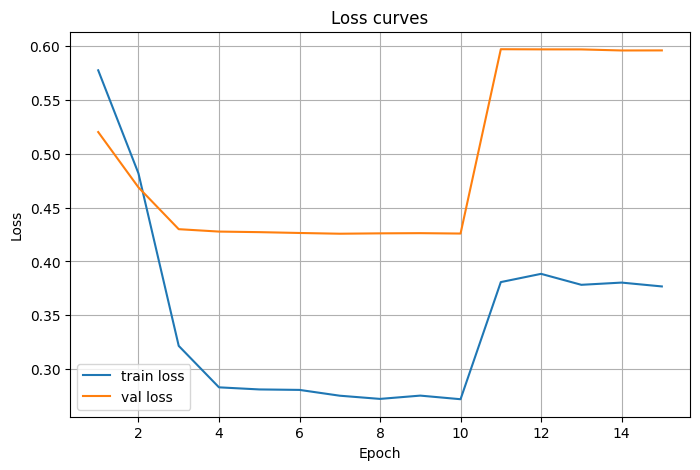

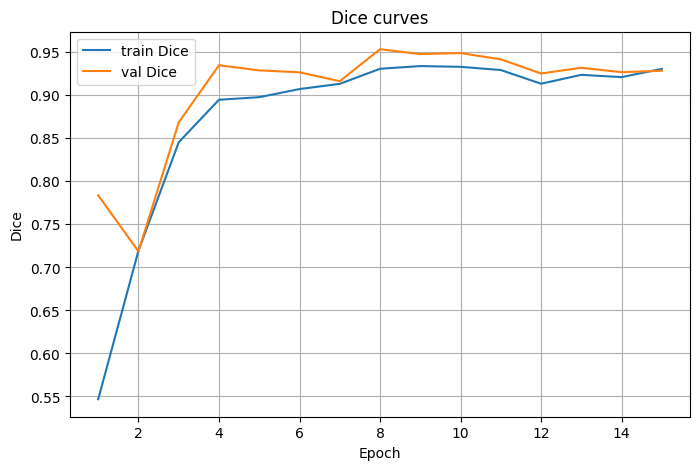

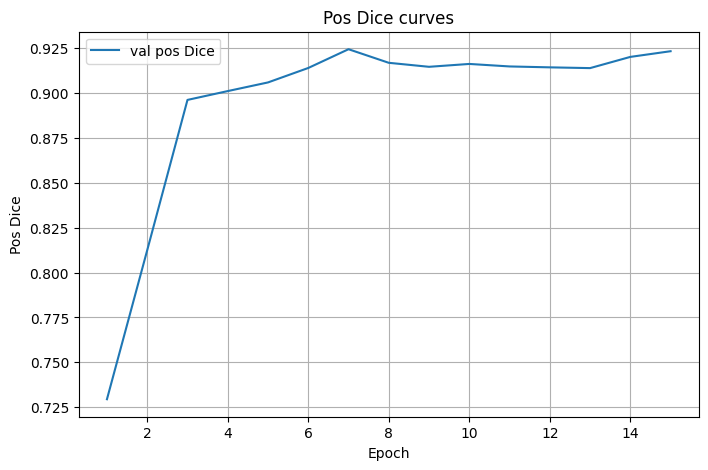

In [43]:
if len(history_df) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["macro_train_dice"], label="train Dice")
    plt.plot(history_df["epoch"], history_df["macro_val_dice"], label="val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Dice curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_pos_dice"], label="val pos Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Pos Dice")
    plt.title("Pos Dice curves")
    plt.legend()
    plt.grid(True)
    plt.show()

## Test evaluation

Only run this after architecture decisions are finalized.


In [44]:
if BEST_CKPT_PATH.exists():
    best_checkpoint = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])

    test_loss, test_metrics, test_sep_metrics, test_lesion_metrics, test_boundary_metrics = validate_one_epoch(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print("Loaded best checkpoint from epoch:", best_checkpoint["epoch"])
    print("Test loss:", round(test_loss, 4))

    print("Test metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    print("Test positive/negative-separated metrics:")
    for k, v in test_sep_metrics.items():
        print(f"{k}: {v}")

    print("Test lesion-level metrics:")
    for k, v in test_lesion_metrics.items():
        print(f"{k}: {v}")

    print("Test HD95 metrics:")
    for k, v in test_boundary_metrics.items():
        print(f"{k}: {v}")

else:
    print("No best checkpoint found.")

Validation:   0%|          | 0/435 [00:00<?, ?it/s]

Loaded best checkpoint from epoch: 8
Test loss: 0.6009
Test metrics:
dice: 0.9511
iou: 0.9470
precision: 0.1429
recall: 0.1411
global_precision: 0.8890
global_recall: 0.9329
Test positive/negative-separated metrics:
positive_slice_dice: 0.9109022325692301
positive_slice_precision: 0.9201991620990965
positive_slice_recall: 0.9087654975277406
negative_slice_mean_fp_pixels: 1.9945541184479239
negative_slice_fp_sample_rate: 0.041524846834581346
num_positive_slices: 540
num_negative_slices: 2938
Test lesion-level metrics:
sensitivity: 0.9356725135255293
precision: 0.7947470809389618
fp_per_slice: 0.060667050028752154
gt_total: 855
pred_total: 1028
fp_lesions_total: 211
Test HD95 metrics:
hd95_pos_mean_px: 7.654683544943906
hd95_pos_median_px: 0.3999999999999986
hd95_pos_count: 513
hd95_gt_no_pred_count: 27


## Qualitative prediction display

Inspect false positives and false negatives. A metric without visual review is not enough in medical segmentation.

In [ ]:
@torch.no_grad()
def visualize_prediction(model, dataset, idx=0, threshold=0.7):
    model.eval()
    item = dataset[idx]

    x = item["image"].unsqueeze(0).to(DEVICE)
    gt = item["mask"][0].cpu().numpy()

    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred = (prob >= threshold).astype(np.float32)

    center = item["image"][1].cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # 1. Original CT image
    axes[0].imshow(center, cmap="gray")
    axes[0].set_title("Center slice")
    axes[0].axis("off")

    # 2. Ground truth mask
    axes[1].imshow(center, cmap="gray")
    axes[1].imshow(
        np.ma.masked_where(gt == 0, gt),
        cmap="Greens",
        alpha=0.7
    )

    axes[1].set_title("Ground_truth Mask")
    axes[1].axis("off")

    # 3. Predicted Mask
    axes[2].imshow(center, cmap="gray")
    axes[2].imshow(
        np.ma.masked_where(pred == 0, pred),
        cmap="Reds",
        alpha=0.7
    )
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    # 4. GT + Prediction on the same image
    axes[3].imshow(center, cmap="gray")
    axes[3].imshow(
        np.ma.masked_where(gt == 0, gt),
        cmap="Greens",
        alpha=0.65
    )
    axes[3].imshow(
        np.ma.masked_where(pred == 0, pred),
        cmap="Reds",
        alpha=0.65
    )

    if gt.max() > 0:
        axes[3].contour(gt, levels=[0.5], colors="lime", linewidths=1.2)
    if pred.max() > 0:
        axes[3].contour(pred, levels=[0.5], colors="red", linewidths=1.2)
    
    axes[3].set_title("Overlay: GT = Green | Pred = Red")
    axes[3].axis("off")

    plt.suptitle(
        f"Case {item['case_id']} | sample {item['sample_idx']} | has_cac={item['has_cac']}"
    )
    plt.tight_layout()
    plt.show()

visualize_prediction(model, test_ds, idx=2800, threshold=cfg.MASK_THRESHOLD)

# Summary

Creating a baseline U-Net
Later add more techniques like Residual + dilated bottleneck variant, HD95 metric, Lesion-level sensitivity

Residual blocks can make deeper transformations easier to optimize by preserving an identity path through the block.
`Dilated conv` enlarge receptve field without further downsampling resolution. Broader context could help distinguish true coronary calcium vs bright nearby non-coronary structures